In [ ]:
import cv2
import numpy as np

# Image size
width, height = 900, 600
img = np.zeros((height, width, 3), dtype=np.uint8)

# -------------------------
# 1. Sunset gradient
# -------------------------
for y in range(height):
    t = y / height

    # Sky colors: blue -> purple -> orange
    if t < 0.65:
        r = int(40 + 180 * t / 0.65)
        g = int(80 - 40 * t / 0.65)
        b = int(180 - 100 * t / 0.65)
    else:
        r = int(220 - 80 * (t - 0.65) / 0.35)
        g = int(100 + 50 * (t - 0.65) / 0.35)
        b = int(70 + 30 * (t - 0.65) / 0.35)

    img[y, :] = (b, g, r)

# -------------------------
# 2. Sun
# -------------------------
cv2.circle(img, (680, 180), 70, (0, 220, 255), -1)
cv2.circle(img, (680, 180), 55, (50, 240, 255), -1)

# -------------------------
# 3. Mountains
# -------------------------
mountains = np.array([
    [0, 400],
    [140, 250],
    [250, 390],
    [390, 210],
    [520, 390],
    [650, 270],
    [800, 400],
    [900, 300],
    [900, 600],
    [0, 600]
])

cv2.fillPoly(img, [mountains], (45, 35, 70))

# Snow peaks
cv2.fillPoly(
    img,
    [np.array([[390, 210], [350, 270], [380, 250],
               [410, 270], [440, 260]])],
    (230, 230, 240)
)

# -------------------------
# 4. Lake
# -------------------------
cv2.rectangle(img, (0, 400), (900, 600), (90, 80, 100), -1)

# Sunset reflection
for i in range(15):
    y = 420 + i * 10
    half_width = int(90 - i * 4)

    cv2.line(
        img,
        (680 - half_width, y),
        (680 + half_width, y),
        (80, 140, 220),
        3
    )

# -------------------------
# 5. Foreground
# -------------------------
cv2.fillPoly(
    img,
    [np.array([
        [0, 520],
        [120, 470],
        [250, 530],
        [400, 490],
        [550, 540],
        [700, 480],
        [900, 530],
        [900, 600],
        [0, 600]
    ])],
    (20, 25, 30)
)

# -------------------------
# 6. Trees
# -------------------------
def tree(x, y, scale=1):
    color = (15, 25, 20)

    cv2.rectangle(
        img,
        (x - int(5 * scale), y),
        (x + int(5 * scale), y + int(70 * scale)),
        color,
        -1
    )

    for i, size in enumerate([45, 35, 25]):
        cy = y - int(i * 25 * scale)
        cv2.circle(img, (x, cy), int(size * scale), color, -1)

tree(100, 490, 1.2)
tree(180, 500, 0.8)
tree(800, 500, 1.3)
tree(850, 510, 0.9)

# -------------------------
# 7. Text
# -------------------------
cv2.putText(
    img,
    "OpenCV Test",
    (30, 60),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (255, 255, 255),
    3,
    cv2.LINE_AA
)

# -------------------------
# 8. Save and display
# -------------------------
cv2.imwrite("opencv_test.png", img)

cv2.imshow("Beautiful OpenCV Test", img)
cv2.waitKey(0)
cv2.destroyAllWindows()


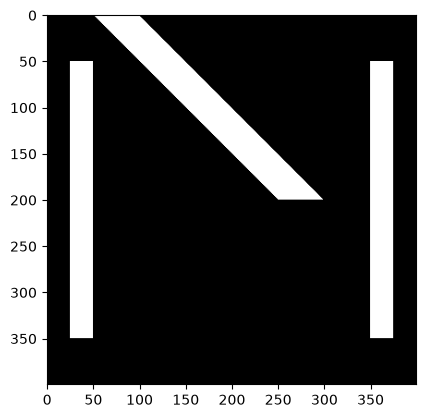

In [25]:
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((400, 400), dtype=np.uint8)

image[50:350, 25:50] = 255
image[50:350, 350:375] = 255

y,x=np.indices((400,400))
image[(x-y>50)&(x-y<100)&(y<200)]=255
plt.imshow(image, cmap="gray")
plt.axis("on")
plt.show()


Shape: (512, 512, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 128.09458033243814


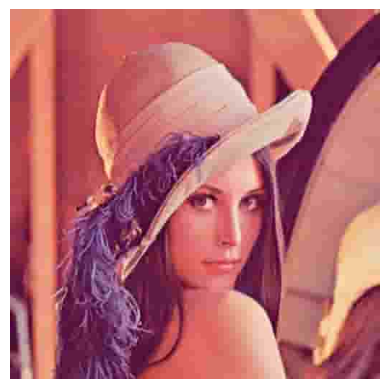

786432


TypeError: only integer scalar arrays can be converted to a scalar index

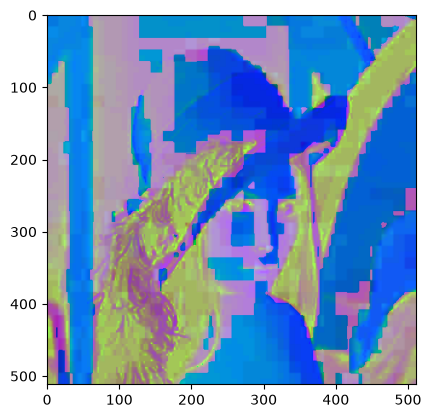

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#image = plt.imread("\\192.168.1.10\shear all\lena5.jpg")
img = Image.open(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
image = np.array(img)

print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum:", image.min())
print("Maximum:", image.max())
print("Mean:", image.mean())

plt.imshow(image)
plt.axis("off")
plt.show()
print(image.nbytes)
import cv2
image = cv2.imread(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
plt.imshow(hsv)

#######         #########

histogram = [0] * 256

# 2. المرور على الصورة وزيادة العداد بسطر واحد داخل اللوب
for row in image:
    for pixel in row:
        histogram[pixel] += 1


# --- الجزء الثاني: رسم الهستوغرام في البرنامج باستخدام Matplotlib ---

# 1. إنشاء قائمة تمثل المحور الأفقي (القيم من 0 إلى 255)
pixel_values = list(range(256))

# 2. إعداد الشكل والمحاور للرسم
plt.figure(figsize=(10, 5)) # تحديد حجم الشكل
plt.title("Grayscale Histogram (Manual Calculation)") # عنوان الرسم
plt.xlabel("Pixel Value (0 - 255)") # تسمية المحور الأفقي
plt.ylabel("Number of Pixels") # تسمية المحور الرأسي

# 3. رسم الأعمدة (Bar Chart)
# plt.bar(المحور_الأفقي, المحور_الرأسي, عرض_العمود, اللون)
plt.bar(pixel_values, histogram, width=1.0, color='gray', edgecolor='black', alpha=0.7)

# 4. تحديد مدى المحور الأفقي ليكون دقيقاً من 0 إلى 255
plt.xlim([-1, 256])

# 5. عرض الرسم
plt.show()


In [52]:
import numpy


Shape: (512, 512, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 128.09458033243814


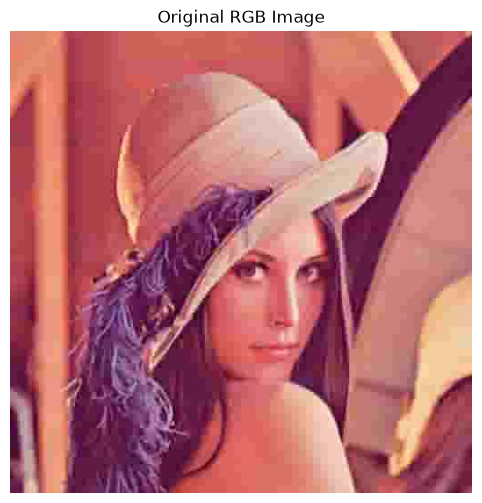

Bytes count: 786432


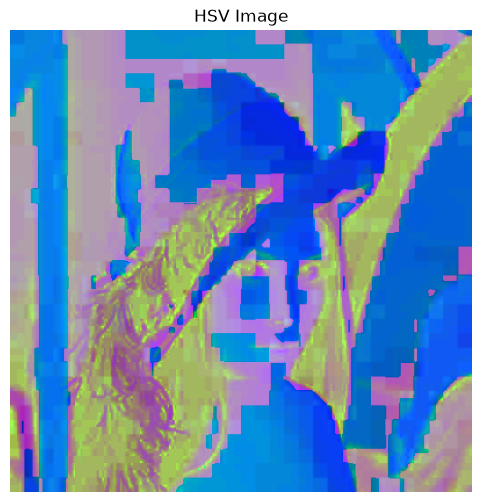

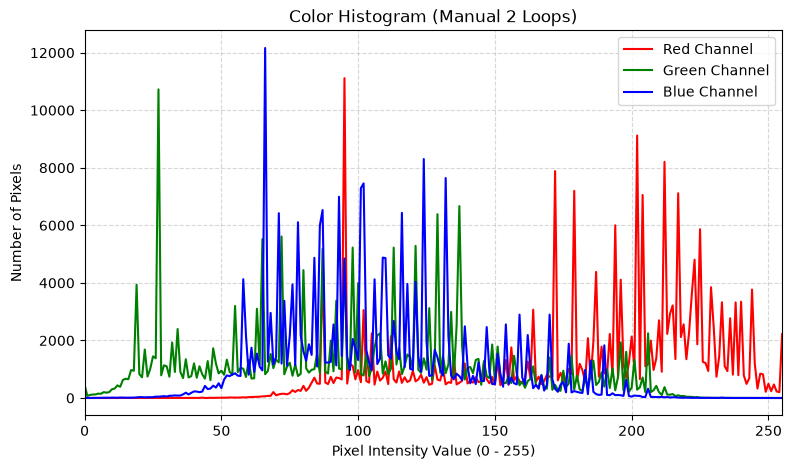

In [56]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- 1. قراءة الصورة واستخراج خصائصها ---
img = Image.open(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
image = np.array(img)

print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum:", image.min())
print("Maximum:", image.max())
print("Mean:", image.mean())

# --- 2. عرض الصورة الأصلية (PIL Image) في نافذة منفصلة ---
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

print("Bytes count:", image.nbytes)

# --- 3. تحويل HSV وعرضه في نافذة منفصلة ---
cv_image = cv2.imread(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(6, 6))
plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")
plt.show()

# --- 4. حساب الهستوغرام الملون يدوياً (2 Loops + سطر داخل اللوب لكل قناة) ---
hist_r = [0] * 256
hist_g = [0] * 256
hist_b = [0] * 256

for row in image:
    for pixel in row:
        hist_r[pixel[0]] += 1
        hist_g[pixel[1]] += 1
        hist_b[pixel[2]] += 1

# --- 5. رسم صورة الهستوغرام الملونة في نافذة منفصلة ---
plt.figure(figsize=(9, 5))

# رسم كل لون باستخدام القيمة واللون المناسب
plt.plot(hist_r, color='red', label='Red Channel', linewidth=1.5)
plt.plot(hist_g, color='green', label='Green Channel', linewidth=1.5)
plt.plot(hist_b, color='blue', label='Blue Channel', linewidth=1.5)

plt.title("Color Histogram (Manual 2 Loops)")
plt.xlabel("Pixel Intensity Value (0 - 255)")
plt.ylabel("Number of Pixels")
plt.legend()
plt.xlim([0, 255])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Shape: (512, 512, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 128.09458033243814
Bytes count: 786432


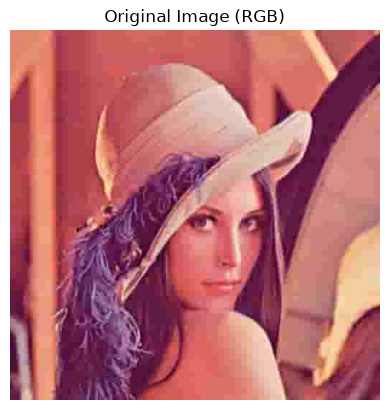

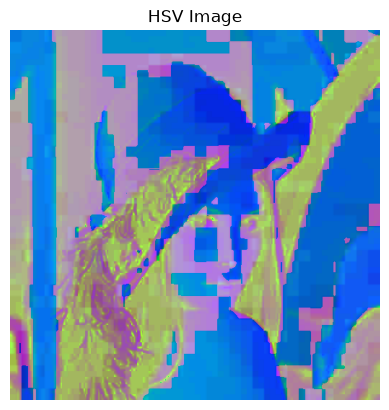

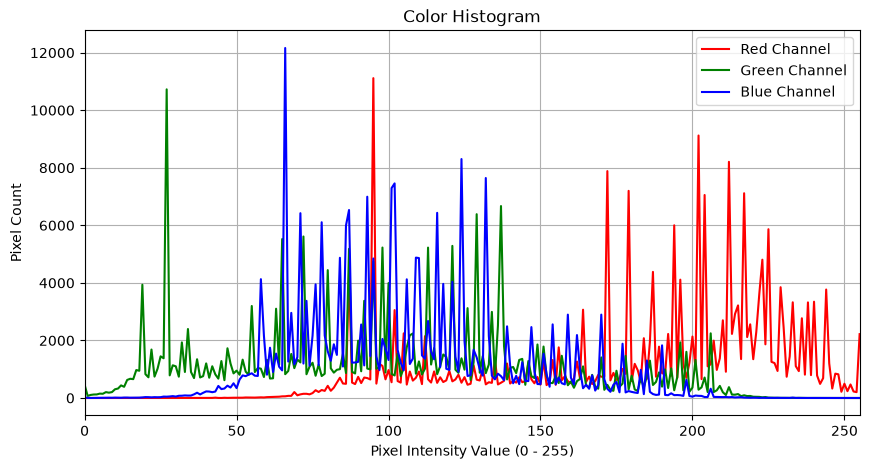

In [57]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. قراءة الصورة واستخراج خصائصها ---
img = Image.open(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
image = np.array(img)

print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum:", image.min())
print("Maximum:", image.max())
print("Mean:", image.mean())
print("Bytes count:", image.nbytes)

# --- 2. عرض الصورة الأصلية في نافذة منفصلة ---
plt.figure()
plt.imshow(image)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

# --- 3. تحويل إلى HSV وعرض الصورة في نافذة منفصلة ---
cv_image = cv2.imread(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)

plt.figure()
plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")
plt.show()

# --- 4. حساب الهستوغرام الملون يدوياً (2 Loops + سطر لكل قناة) ---
hist_r = [0] * 256
hist_g = [0] * 256
hist_b = [0] * 256

for row in image:
    for pixel in row:
        hist_r[pixel[0]] += 1
        hist_g[pixel[1]] += 1
        hist_b[pixel[2]] += 1

# --- 5. رسم الهستوغرام الملون في نافذة منفصلة ---
plt.figure(figsize=(10, 5))

# رسم القنوات الملونة بالأحمر والأخضر والأزرق
plt.plot(hist_r, color='red', label='Red Channel')
plt.plot(hist_g, color='green', label='Green Channel')
plt.plot(hist_b, color='blue', label='Blue Channel')

plt.title("Color Histogram")
plt.xlabel("Pixel Intensity Value (0 - 255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.xlim([0, 255])
plt.grid(True)

# أمر إظهار الرسم البياني للهستوغرام في البرنامج
plt.show()

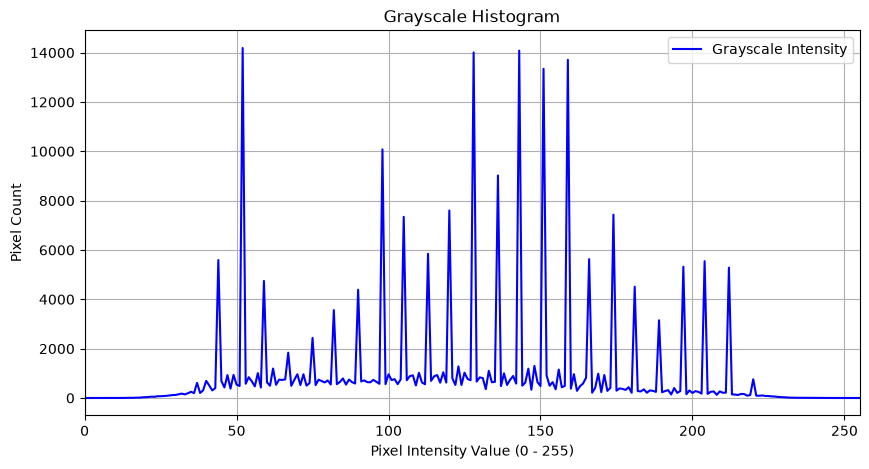

In [59]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. قراءة الصورة ---
img = Image.open(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
image = np.array(img)

# --- 2. تحويل الصورة إلى رمادي (Grayscale) ---
if len(image.shape) == 3:
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
else:
    gray_image = image

# --- 3. حساب الهستوغرام يدوياً (2 Loops + سطر واحد داخل اللوب) ---
histogram = [0] * 256

for row in gray_image:
    for pixel in row:
        histogram[pixel] += 1  # سطر واحد لتزويد العداد

# --- 4. رسم الهستوغرام بخط واحد فقط ---
plt.figure(figsize=(10, 5))

# رسم خط واحد يمثل شدة الإضاءة الرمادية
plt.plot(histogram, color='blue', linewidth=1.5, label='Grayscale Intensity')

plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity Value (0 - 255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.xlim([0, 255])
plt.grid(True)

plt.show()

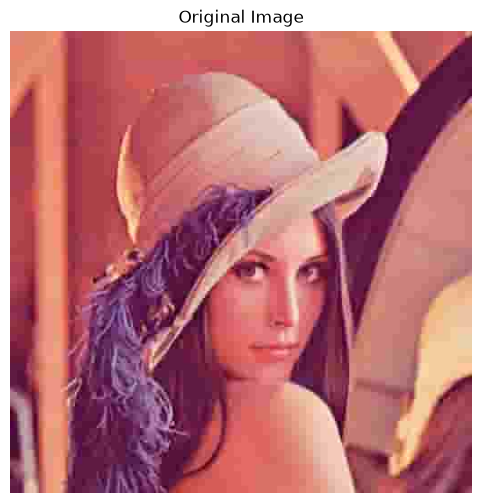

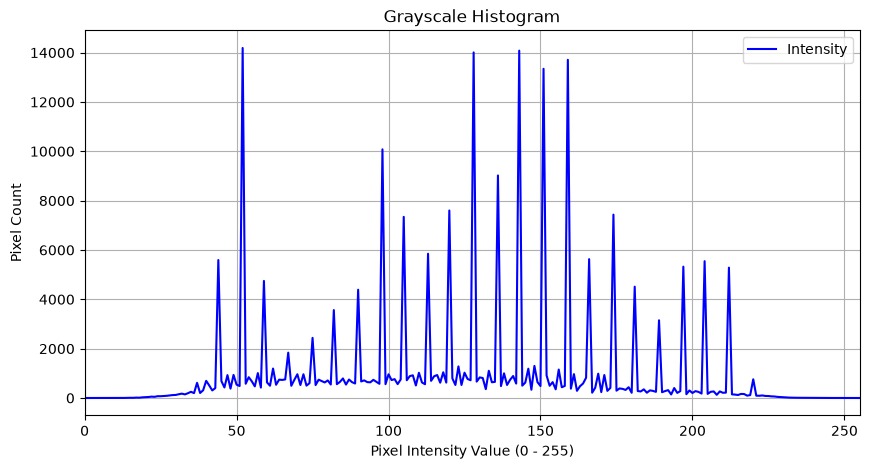

In [61]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. قراءة الصورة الأصلية ---
img = Image.open(r"c:\Users\PC-LAB1\Desktop\lena5.jpg")
image = np.array(img)

# --- 2. عرض الصورة الأصلية في الفيقر الأول (Figure 1) ---
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# --- 3. تحويل الصورة إلى رمادي (Grayscale) لحساب خط هستوغرام واحد ---
if len(image.shape) == 3:
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
else:
    gray_image = image

# --- 4. حساب الهستوغرام يدوياً (2 Loops + سطر واحد داخل اللوب) ---
histogram = [0] * 256

for row in gray_image:
    for pixel in row:
        histogram[pixel] += 1

# --- 5. رسم الهستوغرام بخط واحد في فيقر منفصل (Figure 2) ---
plt.figure(figsize=(10, 5))

plt.plot(histogram, color='blue', linewidth=1.5, label='Intensity')

plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity Value (0 - 255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.xlim([0, 255])
plt.grid(True)

plt.show()

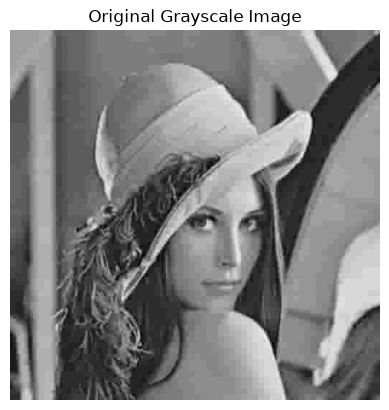

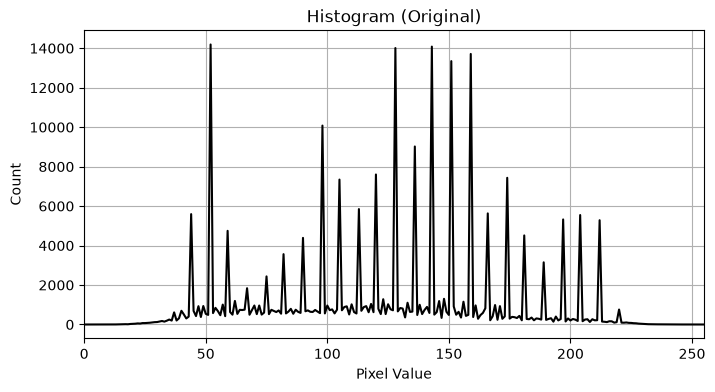

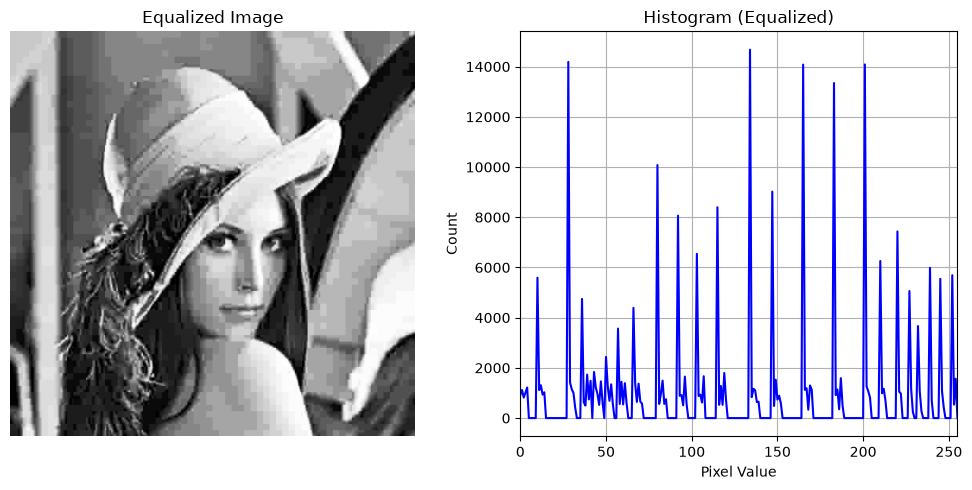

In [62]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. قراءة الصورة وتحويلها لرمادي ---
img_path = r"c:\Users\PC-LAB1\Desktop\lena5.jpg"
img = Image.open(img_path)
image_rgb = np.array(img)

if len(image_rgb.shape) == 3:
    gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
else:
    gray_image = image_rgb

# --- 2. عرض الصورة الأصلية في نافذة منفصلة (Figure 1) ---
plt.figure()
plt.imshow(gray_image, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# --- 3. حساب الهستوغرام الرمادي الأساسي يدوياً (الذي قمت به) ---
hist_original = [0] * 256
for row in gray_image:
    for pixel in row:
        hist_original[pixel] += 1

# --- 4. عرض الهستوغرام الأساسي بخط واحد في نافذة منفصلة (Figure 2) ---
plt.figure(figsize=(8, 4))
plt.plot(hist_original, color='black', label='Original Intensity')
plt.title("Histogram (Original)")
plt.xlabel("Pixel Value")
plt.ylabel("Count")
plt.xlim([0, 255])
plt.grid(True)
plt.show()

# --- 5. تنفيذ Histogram Equalization يدوياً (الخطوات الإضافية) ---

# أ. حساب التكرار التجميعي (Cumulative Distribution Function - CDF)
cdf = [0] * 256
current_sum = 0
for i in range(256):
    current_sum += hist_original[i]
    cdf[i] = current_sum

# ب. تطبيع الـ CDF وتعيينه إلى نطاق (0-255) لإنشاء خريطة التحويل
num_pixels = gray_image.size
cdf_min = min([c for c in cdf if c > 0]) # استبعاد القيم الصفرية لتجنب التشوه

# دالة تحويل لكل قيمة بكسل قديمة r إلى قيمة جديدة s
mapping = [0] * 256
for r in range(256):
    if cdf[r] > 0:
        # القانون: (cdf[r] - cdf_min) / (total - cdf_min) * 255
        mapping[r] = int(((cdf[r] - cdf_min) / (num_pixels - cdf_min)) * 255)
    else:
        mapping[r] = 0

# ج. تطبيق خريطة التحويل على الصورة الأصلية (إنشاء الصورة الجديدة)
# نستخدم دالة مصفوفة Numpy سريعة لتطبيق الـ mapping
equalized_image = np.array([mapping[pixel] for pixel in gray_image.flatten()]).reshape(gray_image.shape).astype(np.uint8)

# د. حساب هستوغرام الصورة الجديدة المحسنة (للتحقق)
hist_equalized = [0] * 256
for row in equalized_image:
    for pixel in row:
        hist_equalized[pixel] += 1

# --- 6. عرض الصورة المحسنة وهستوغرامها الجديد في نافذة منفصلة (Figure 3) ---
plt.figure(figsize=(10, 5))

# الصورة الجديدة
plt.subplot(1, 2, 1)
plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis("off")

# الهستوغرام الجديد (يجب أن يكون أكثر توزيعاً)
plt.subplot(1, 2, 2)
plt.plot(hist_equalized, color='blue', label='Equalized Intensity')
plt.title("Histogram (Equalized)")
plt.xlabel("Pixel Value")
plt.ylabel("Count")
plt.xlim([0, 255])
plt.grid(True)

plt.tight_layout()
plt.show()

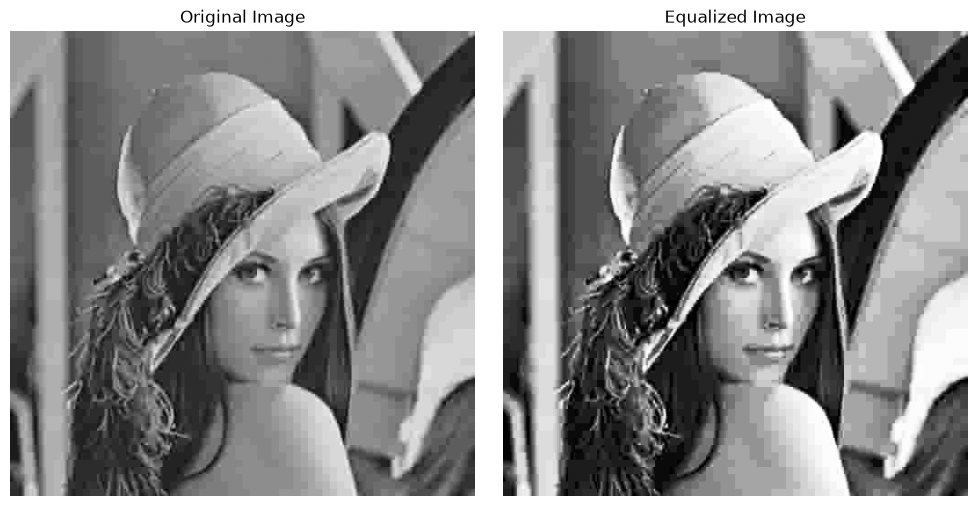

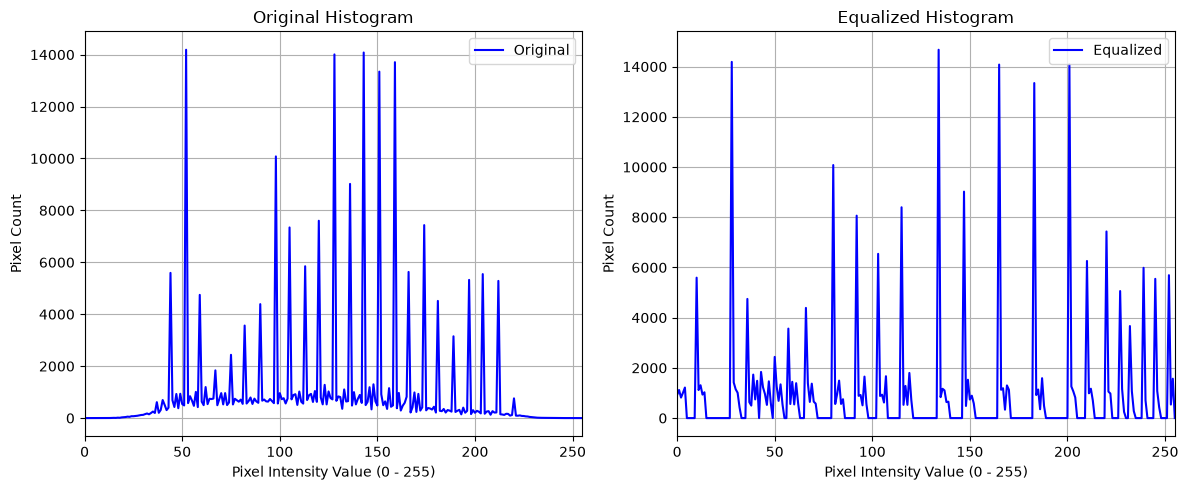

In [64]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. قراءة الصورة وتحويلها لرمادي ---
img_path = r"c:\Users\PC-LAB1\Desktop\lena5.jpg"
img = Image.open(img_path)
image_rgb = np.array(img)

if len(image_rgb.shape) == 3:
    gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
else:
    gray_image = image_rgb

# --- 2. حساب الهستوغرام الأصلي يدوياً (2 Loops + سطر واحد) ---
hist_original = [0] * 256
for row in gray_image:
    for pixel in row:
        hist_original[pixel] += 1

# --- 3. تطبيق Histogram Equalization يدوياً ---

# أ. حساب التكرار التجميعي (CDF)
cdf = [0] * 256
current_sum = 0
for i in range(256):
    current_sum += hist_original[i]
    cdf[i] = current_sum

# ب. إنشاء خريطة تحويل القيم (Mapping)
num_pixels = gray_image.size
cdf_min = min([c for c in cdf if c > 0])

mapping = [0] * 256
for r in range(256):
    if cdf[r] > 0:
        mapping[r] = int(((cdf[r] - cdf_min) / (num_pixels - cdf_min)) * 255)
    else:
        mapping[r] = 0

# ج. إنشاء الصورة المعدلة
equalized_image = np.array([mapping[pixel] for pixel in gray_image.flatten()]).reshape(gray_image.shape).astype(np.uint8)

# د. حساب هستوغرام الصورة المعدلة يدوياً
hist_equalized = [0] * 256
for row in equalized_image:
    for pixel in row:
        hist_equalized[pixel] += 1


# --- 4. الفيقر الأول: عرض الصور (الأصلية والمعدلة) معاً ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()


# --- 5. الفيقر الثاني: عرض الهستوغرامات (الأصلي والمعدل) معاً ---
plt.figure(figsize=(12, 5))

# الهستوغرام الأصلي (بخطي واحد)
plt.subplot(1, 2, 1)
plt.plot(hist_original, color='blue', linewidth=1.5, label='Original')
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity Value (0 - 255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.xlim([0, 255])
plt.grid(True)

# الهستوغرام المعدل (بخطي واحد)
plt.subplot(1, 2, 2)
plt.plot(hist_equalized, color='blue', linewidth=1.5, label='Equalized')
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity Value (0 - 255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.xlim([0, 255])
plt.grid(True)

plt.tight_layout()
plt.show()